<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter7/7_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 심층신경망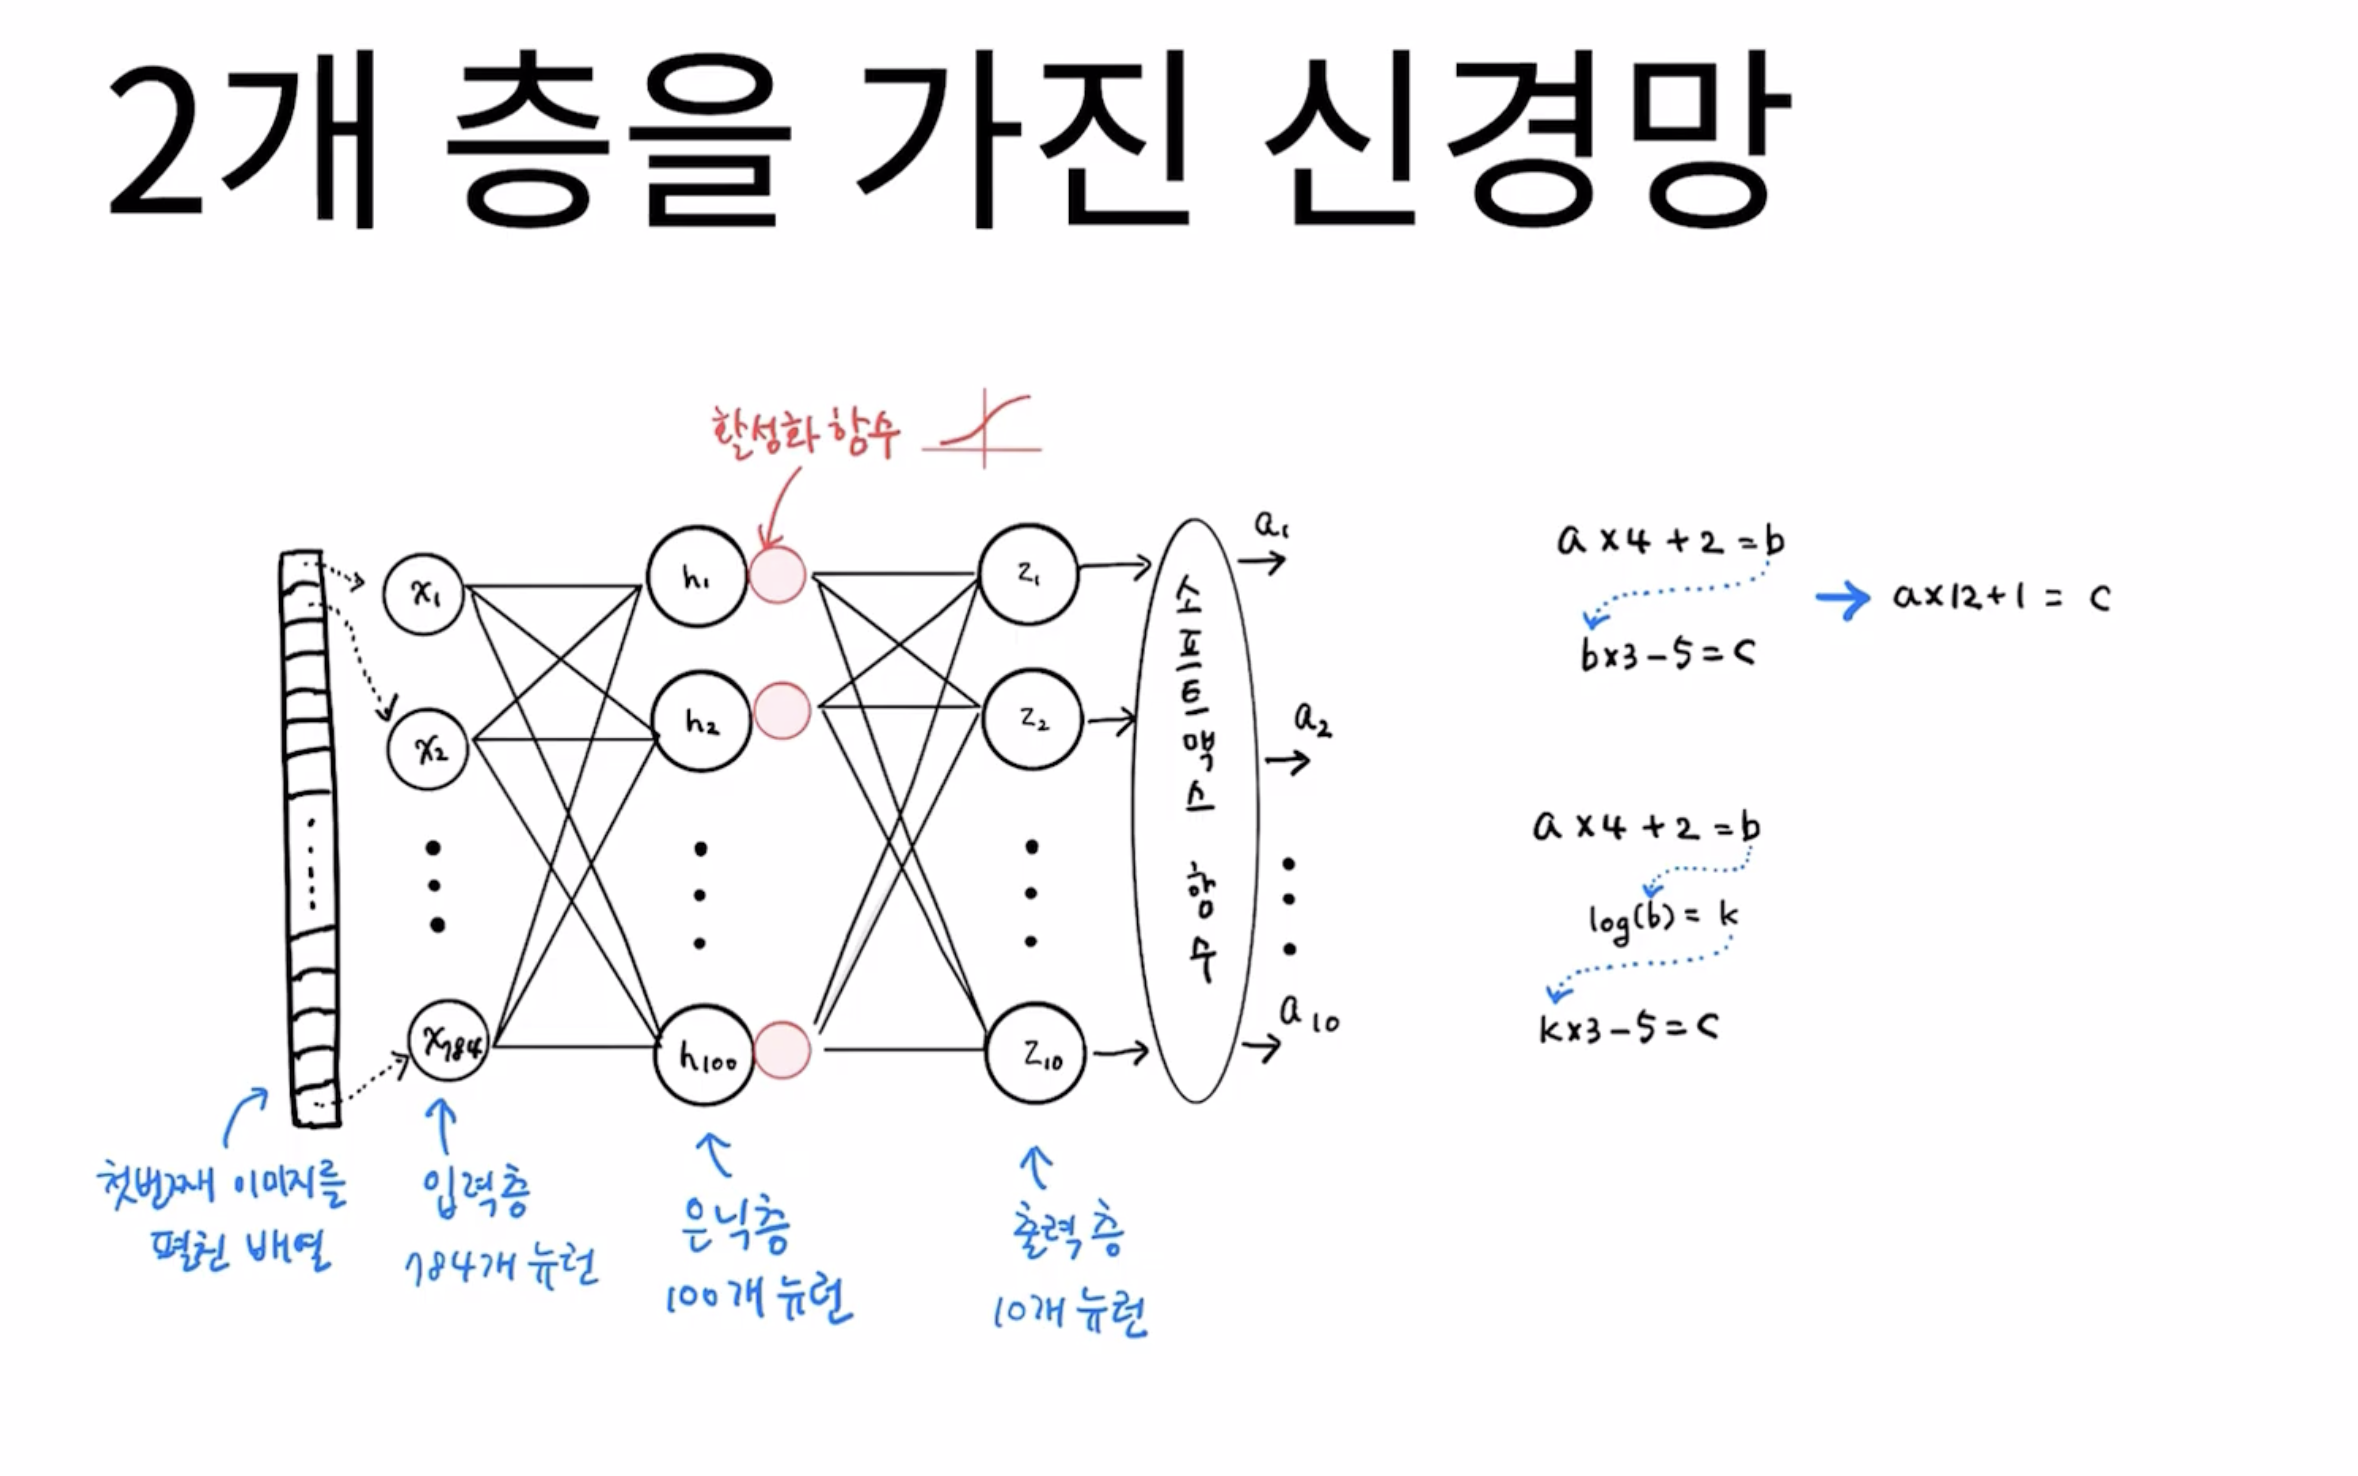

In [3]:
#데이터 가져오기
import keras
(train_input, train_target), (test_input, test_target) = \
keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
#데이터 전처리
from sklearn.model_selection import train_test_split

train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)
train_scaled, val_input, train_target, val_target = train_test_split(train_scaled,train_target,
                                                                     test_size=0.2, random_state=42)

In [5]:
#심층신경망 만들기
#입력층
inputs = keras.layers.Input(shape=(784,))
#은닝층(100 로 둔것은 임의. 최적의 값을 찾아야함.)
dense1 = keras.layers.Dense(100, activation='sigmoid')
#출력층
dense2 =keras.layers.Dense(10, activation='softmax')

#심층신경망 모델
model = keras.Sequential([inputs, dense1, dense2])

#모델 요약
model.summary()

#output shape에서 첫번째 차원이 none. none은 아직 샘플의 개수가 정해지지 않아서.파라미터는 784*100 + 100 (뒤에 100은 절편)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

## 여러가지 모델 생성 방법

In [8]:
#층을 추가하는 다른 방법(seqeuntial 클래스에 층을 추가하는 다른 방법)
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(100, activation='sigmoid', name= '은닉층'),
    keras.layers.Dense(10, activation='softmax', name= '출력층')
], name='패션 MNIST 모델')

#모델 요약(정리 및 이름 붙임)
model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 은닉층 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 출력층 (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#하나씩 추가하는법 add()(사람들이 많이 쓰는 방법, 층을 많이 추가하면 클래스 생성자가 매우 길어지기 때문에)
model = keras.Sequential()
model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(100, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

#모델 요약
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#모델 훈련해보기
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8060 - loss: 0.5674
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8510 - loss: 0.4119
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8632 - loss: 0.3765
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8717 - loss: 0.3534
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8784 - loss: 0.3361


## 렐루 함수와 Flatten층

초창기 은닝층에 많이 사용된 활성화 함수는 시그모이드 함수였지만 오른쪽과 왼쪽 끝으로 갈수록 누워있어 올바른 출력을 만드는데 신속한 대응을 하지 못한다는 단점 때문에 렐루 함수가 제안됨.

렐루 함수는 입력이 양수일 경우 마치 활성화 함수가 없는 것처럼 그냥 입력을 통과시키고 음수일 경우에는 0으로 만듦.
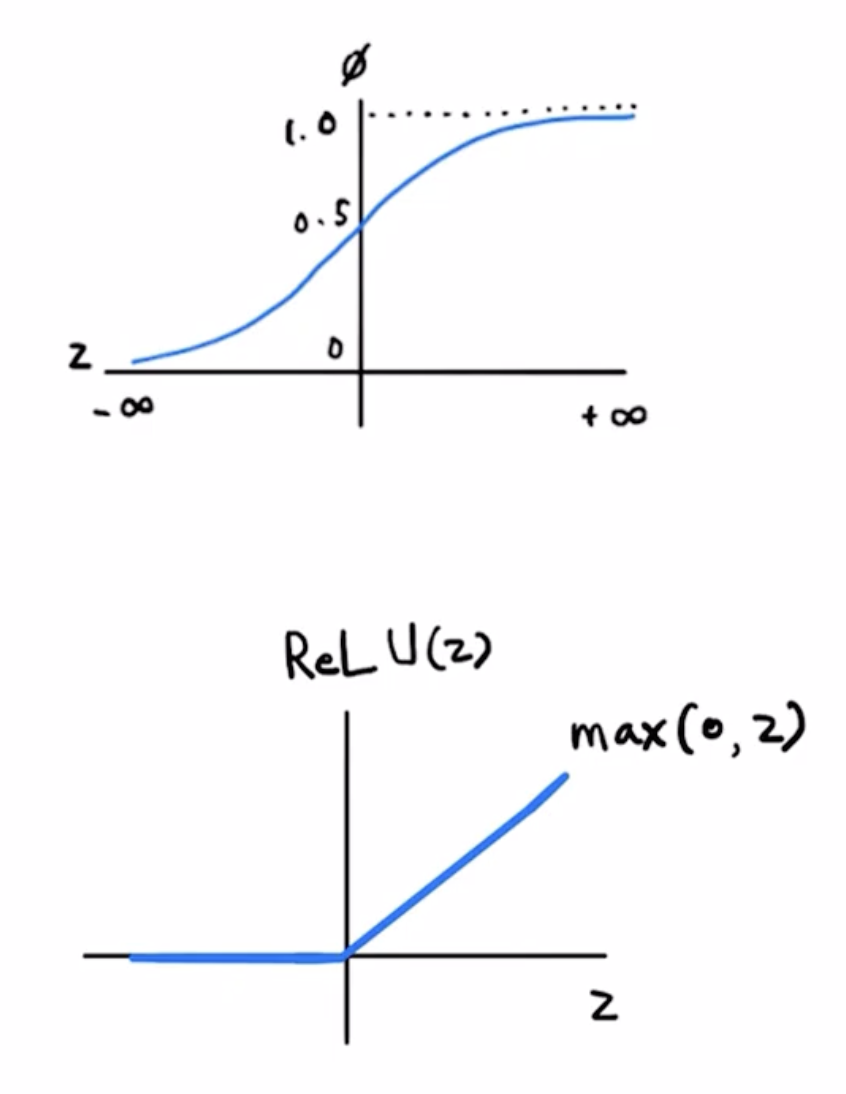

In [13]:
#케라스에서는 1차원 배열로 펼치기 위한 Flatten 층이 존재.
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28))) #2차원
model.add(keras.layers.Flatten())  #1차원 펼치기
model.add(keras.layers.Dense(100, activation='relu')) #렐루함수 사용
model.add(keras.layers.Dense(10, activation='softmax'))

#모델 요약
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#훈련 데이터를 준비해서 모델 훈련
(train_input, train_target), (test_input, test_target) = \
keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0 #앞과 달리 reshape 적용하지 않음

train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled,train_target,
                                                                     test_size=0.2, random_state=42)

In [17]:
#모델 컴파일 및 훈련
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8928 - loss: 0.3028
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8954 - loss: 0.2947
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8985 - loss: 0.2845
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9021 - loss: 0.2779
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9038 - loss: 0.2715


In [18]:
#검증 세트에서의 성능 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8637 - loss: 0.4669


[0.466865599155426, 0.8637499809265137]

## 옵티마이저(최적화 하이퍼파라미터)

렐루 함수까지 쓰니 성능이 향상됨을 볼수 있음. 지금까지 에포크를 5번 훈련했는데 더 하지 않을 이유가 없음.

인공신경망에는 사람이 지정해줘야하는 하이퍼파라미터가 많음.

은닉층의 개수, 은닉층의 뉴런 개수, 활성화 함수 선택, 층의 종류, 에포크, 심지어 케라스는 기본적으로 미니배치 경사 하강법을 사용하는데 미니배치 개수가 32개. 이것조차 조정할수 있는 하이퍼파라미터.

케라스는 기본 경사 하강법 알고리즘인 RMSprop를 사용하는데 이것 외에 다양한 종류의 경사 하강법 알고리즘을 제공함.

이들을 옵티마이저라고 부름.

In [19]:
#다양한 옵티마이저 테스트해보기
#SGD 옵티마이저(기본 경사 하강법)
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#위와 완전히 동일. 하지만 클래스 지정
sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#클래스를 지정해서 해줘야하는 이유는 학습률을 바꿀수 있기 때문
sgd = keras.optimizers.SGD(learning_rate=0.1)


In [20]:
#모멘텀 최적화, 네스테로프 모멘텀 최적화(모멘텀최적화 2번 반복)(SGD)
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

In [21]:
#적응적 학습률 옵티마이저
#아다그라드
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#RMSprop
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Adam(RMSprop와 함께 맨처음 시도해 볼 수있는 좋은 알고리즘)
adam = keras.optimizers.Adam()
model.compile(optimizer=adam, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [24]:
#Adam 클래스로 패션 MNIST 모델 훈련
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [25]:
#컴파일 및 훈련
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8167 - loss: 0.5240
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8571 - loss: 0.3980
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8693 - loss: 0.3569
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8796 - loss: 0.3292
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8862 - loss: 0.3103


In [26]:
#검증 세트 성능 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8779 - loss: 0.3427


[0.34271809458732605, 0.877916693687439]